In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

Matplotlib is building the font cache; this may take a moment.


In [5]:
# benchmarks
gemma = pd.read_csv('benchmark_results_gemma4-12b.csv')
ornith = pd.read_csv('benchmark_results_ornith1.5-9b.csv')
qwen14b = pd.read_csv('benchmark_results_qwen3-14b.csv')
qwen9b = pd.read_csv('benchmark_results_qwen3.5-9b.csv')

In [6]:
gemma.head()

,model,prompt_id,category,run_index,correct_tool,args_valid,latency,timestamp
0,gemma4:12b,p1,should_call,0,True,True,34.257748,1.787209e+09
1,gemma4:12b,p1,should_call,1,False,NaN,37.875905,1.787209e+09
2,gemma4:12b,p1,should_call,2,True,True,32.546269,1.787209e+09
3,gemma4:12b,p1,should_call,3,True,True,32.511773,1.787209e+09
4,gemma4:12b,p1,should_call,4,True,True,25.772430,1.787209e+09


Three main things I am looking for:

- **Per-category breakdown**, not just overall accuracy. For example, should_not_call failures (calling a tool when it shouldn't) are a worse failure mode for an agent than a missed should_call, so they're worth weighting differently, not averaging together.
- **Consistency** across the 5 runs, not just the mean. If a model is right 5/5 times on a prompt that's more trustworthy than one averaging the same rate at 3/5, even if aggregate accuracy matches.
- **Latency**, since this all runs locally on my hardware and speed is a real cost.

In [49]:
df = pd.concat([gemma, ornith, qwen14b, qwen9b ], ignore_index=True)
df['correct_tool'] = df['correct_tool'].astype(float)
df

,model,prompt_id,category,run_index,correct_tool,args_valid,latency,timestamp
0,gemma4:12b,p1,should_call,0,1.0,True,34.257748,1.787209e+09
1,gemma4:12b,p1,should_call,1,0.0,NaN,37.875905,1.787209e+09
2,gemma4:12b,p1,should_call,2,1.0,True,32.546269,1.787209e+09
3,gemma4:12b,p1,should_call,3,1.0,True,32.511773,1.787209e+09
4,gemma4:12b,p1,should_call,4,1.0,True,25.772430,1.787209e+09
...,...,...,...,...,...,...,...,...
395,qwen3.5:9b,p20,multi_tool,0,0.0,NaN,8.315333,1.787294e+09
396,qwen3.5:9b,p20,multi_tool,1,0.0,NaN,4.731653,1.787294e+09
397,qwen3.5:9b,p20,multi_tool,2,0.0,NaN,5.076807,1.787294e+09
398,qwen3.5:9b,p20,multi_tool,3,0.0,NaN,4.445831,1.787294e+09


## Per-category breakdown

In [50]:
df.groupby(['model', 'category'])['correct_tool'].mean().unstack('category')

category,ambiguous,multi_tool,should_call,should_not_call
model,,,,
gemma4:12b,NaN,0.000000,0.92,1.00
ornith-1.5:9b,NaN,0.000000,0.72,1.00
qwen3.5:9b,NaN,0.000000,0.96,0.92
qwen3:14b,NaN,0.533333,0.96,0.88


a model that fabricates tool calls it shouldn't (e.g. writing a file, sending something) is a different kind of problem than one that's merely less capable, and a weighted blend lets a good should_call score paper over that. So qwen models so far looking worse. However only qwen3:14b was able to pick up some of the multitool calls.

In [59]:
per_prompt = df.groupby(['model', 'prompt_id'])['correct_tool'].mean().reset_index()
per_prompt = per_prompt.sort_values(
    ['model', 'prompt_id'],
    key=lambda col: col.str[1:].astype(int) if col.name == 'prompt_id' else col
)

In [60]:
scored = df[df['category'] != 'ambiguous']
_per_prompt = scored.groupby(['model', 'prompt_id'])['correct_tool'].mean().reset_index()

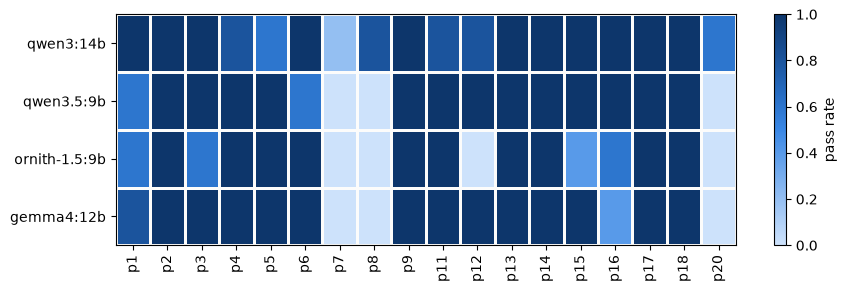

In [61]:
pivot = _per_prompt.pivot(index='model', columns='prompt_id', values='correct_tool')
pivot = pivot[sorted(pivot.columns, key=lambda p: int(p[1:]))]

blue_ramp = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
cmap = LinearSegmentedColormap.from_list("seq_blue", blue_ramp)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.pcolormesh(pivot.values, cmap=cmap, vmin=0, vmax=1,
                   edgecolors="#fcfcfb", linewidth=2)  # 2px gap between cells
ax.set_xticks(np.arange(len(pivot.columns)) + 0.5, pivot.columns, rotation=90)
ax.set_yticks(np.arange(len(pivot.index)) + 0.5, pivot.index)
fig.colorbar(im, ax=ax, label="pass rate")

In [62]:
per_prompt.head(20)

,model,prompt_id,correct_tool
0,gemma4:12b,p1,0.8
11,gemma4:12b,p2,1.0
13,gemma4:12b,p3,1.0
14,gemma4:12b,p4,1.0
15,gemma4:12b,p5,1.0
16,gemma4:12b,p6,1.0
17,gemma4:12b,p7,0.0
18,gemma4:12b,p8,0.0
19,gemma4:12b,p9,1.0
1,gemma4:12b,p10,NaN


Interesting to cherypick and see what exact prompts models failed at, since my benchamark is pretty small:

**gemma4:12b**:

p1: "What's the weather in Victoria?" expects the get_weather tool. It called the right tool 4 out of 5 times, scoring 0.8.

p7: "Read notes.pdf and summarize it into summary.md" expects the multitool pair read_pdf and write_file. I do have a separate read_file tool, so the model may have called that instead of read_pdf, which my grading flagged as the wrong tool - though I can't actually confirm this without the raw tool call logged. It's a genuinely ambiguous prompt, and the model may have failed to distinguish between read_file and read_pdf. That said, it correctly called read_pdf on p3 ("Open notes.pdf and tell me what's in it"), so the confusion isn't consistent.

p8: "Check the weather in Paris and save it to weather.md" expects the multitool pair get_weather and write_file.

p16: "Is it true the Great Wall of China is visible from space?" expects fact_check with arguments {"claim": "great wall of china"}. Scored 0.4, meaning it called the right tool in only 2 of 5 runs. It's a totally valid response either way.

p20: "Search for the current Python version and save it to versions.md" expects the multitool pair web_search and write_file. This one is ambiguous in its own way - "current Python version" could plausibly be read as asking about the Python version installed in the current environment rather than the latest release.


In [52]:
per_prompt[20:40]

,model,prompt_id,correct_tool
20,ornith-1.5:9b,p1,0.6
31,ornith-1.5:9b,p2,1.0
33,ornith-1.5:9b,p3,0.6
34,ornith-1.5:9b,p4,1.0
35,ornith-1.5:9b,p5,1.0
36,ornith-1.5:9b,p6,1.0
37,ornith-1.5:9b,p7,0.0
38,ornith-1.5:9b,p8,0.0
39,ornith-1.5:9b,p9,1.0
21,ornith-1.5:9b,p10,NaN


**ornith-1.5:9b**:

Similar situation to gemma4:12b, with p7, p8, and p20 failing, and p1 and p16 scoring partial credit.

p3 ("Open notes.pdf and tell me what's in it") failed 2 out of 5 times.

p15 ("What's the latest stable version of Python?") failed to call web_search in 3 out of 5 runs.

p12 ("Can you read my lecture_notes.md and summarize it?"), which expects read_file, failed all 5 out of 5 runs.

In [64]:
per_prompt[40:60]

,model,prompt_id,correct_tool
40,qwen3.5:9b,p1,0.6
51,qwen3.5:9b,p2,1.0
53,qwen3.5:9b,p3,1.0
54,qwen3.5:9b,p4,1.0
55,qwen3.5:9b,p5,1.0
56,qwen3.5:9b,p6,0.6
57,qwen3.5:9b,p7,0.0
58,qwen3.5:9b,p8,0.0
59,qwen3.5:9b,p9,1.0
41,qwen3.5:9b,p10,NaN


**qwen3.5:9b**:

Failed the multitool prompts p7, p8, and p20, and had some trouble with p1.

It also scored 0.6 on p6 ("Write me a haiku about the ocean"). Most likely, in 2 out of 5 runs it tried to call a tool it didn't need - a should_not_call failure, though not a critical one.

Other than that, the model performed really well, especially considering it's roughly 25% smaller than gemma4.

In [65]:
per_prompt[60:80]

,model,prompt_id,correct_tool
60,qwen3:14b,p1,1.0
71,qwen3:14b,p2,1.0
73,qwen3:14b,p3,1.0
74,qwen3:14b,p4,0.8
75,qwen3:14b,p5,0.6
76,qwen3:14b,p6,1.0
77,qwen3:14b,p7,0.2
78,qwen3:14b,p8,0.8
79,qwen3:14b,p9,1.0
61,qwen3:14b,p10,NaN


**qwen3:14b**:

As expected, qwen3:14b performed better than the smaller models. It was the only model able to make any progress on the multitool prompts p7, p8, and p20 - though p7 was still called correctly only once out of 5 runs.

p4 and p5 are actual should_not_call errors for this model. On p4 it got 4 of 5 right, and on p5, 3 of 5 - meaning in a handful of runs it called a tool when it shouldn't have. Separately, p11 and p12 each had one should_call miss out of 5 (0.8 each).

This raises a real question about evaluating this model. It's already the largest and most resource-hungry candidate, and its latency was significantly higher than the rest. Combined with the should_not_call slippage, it seems like on average this model would eat noticeably more time, memory, and tokens than the other candidates. However, it was the only model that made real progress on multitool calls, and was otherwise near-perfect on single-tool should_call prompts.

This makes me want to keep this model available separately as an option for more complex tasks, but definitely not as the main agent.

## Latency

In [63]:
df.groupby('model')['latency'].median()

model
gemma4:12b        9.893396
ornith-1.5:9b     5.509050
qwen3.5:9b        6.595725
qwen3:14b        16.555896
Name: latency, dtype: float64

This makes sense, the smaller the model the faster it produced results

## Closer look at multitool failures

In [ ]:
import json

multitool = pd.read_csv('multitool_diagnostic.csv')
for _, row in multitool.iterrows():
    calls = json.loads(row['tool_calls'])
    call_summary = ', '.join(f"{c['name']}({c['arguments']})" for c in calls) if calls else '(no tool call)'
    print(f"{row['model']:15s} {row['prompt_id']:4s} correct={str(row['correct_tool']):5s} -> {call_summary}")
    text = row['response_content']
    if isinstance(text, str) and text.strip():
        print(f"{'':15s}      text: {text.strip()[:100]}")

The grader says 0% on p7, p8, and p20 for three of the four models, but the raw tool calls tell a different story.

**gemma4:12b, qwen3.5:9b, and qwen3:14b** all called `read_pdf` with the correct path on p7, then stopped. That's the sensible move: you can't write a summary of a file you haven't read yet, and a single `ollama.chat()` call never gives the model back a tool result to pass into `write_file`. The multi_tool grading (both tools called in the same turn) tests something that doesn't match how tool use actually works in a real agent loop - call a tool, get the result, then decide the next call.

**ornith-1.5:9b** is the real outlier: it called `list_directory` instead of `read_pdf` on p7, and `list_directory` alongside `web_search` on p20. That's a genuine wrong-tool error, not a sequencing artifact.

**qwen3:14b**'s one graded "success" (p8) is the most important finding here. It wrote `{'temperature': 15, 'condition': 'Partly Cloudy'}` to `weather.md` without ever calling `get_weather` first - there's no tool-result round trip in this format, so it fabricated a plausible-looking weather report. Passing the grader by hallucinating is arguably worse than the other models' conservative one-tool-and-stop behavior. That call also cost 103.9s on p7 alone, far above its 16.6s median latency.

**Takeaway:** multi_tool, as graded here, can't tell good sequential tool use apart from bad. Testing it properly needs a real loop - execute the tool, feed the result back, see what the model does next - not a single completion. Treating this category as informational rather than a factor in the model decision.

## Consistency

In [ ]:
per_prompt_consistency = scored.groupby(['model', 'prompt_id'])['correct_tool'].mean()
flaky = per_prompt_consistency.groupby('model').apply(lambda s: ((s > 0) & (s < 1)).sum())
total = per_prompt_consistency.groupby('model').size()
pd.DataFrame({'flaky_prompts': flaky, 'total_prompts': total, 'flaky_rate': (flaky / total).round(2)})

qwen3:14b has the best average accuracy but the least consistent behavior: 7 of its 18 scored prompts (39%) landed strictly between 0 and 1 across the 5 runs - more than any other model. gemma4:12b and qwen3.5:9b are the most consistent (2 of 18, 11%): when they get a prompt right, they tend to get it right every time. ornith-1.5:9b sits in between (4 of 18, 22%).

This is a third reason not to default to qwen3:14b: part of its higher mean accuracy comes from being less deterministic, not just more capable. A model that sometimes gets a prompt right and sometimes doesn't is harder to build reliable agent behavior around than one that fails the same way every time.

## Conclusion

| model | should_call | should_not_call | latency (median) | flaky prompts |
|---|---|---|---|---|
| gemma4:12b | 0.92 | 1.00 | 9.9s | 2/18 |
| ornith-1.5:9b | 0.72 | 1.00 | 5.5s | 4/18 |
| qwen3.5:9b | 0.96 | 0.92 | 6.6s | 2/18 |
| qwen3:14b | 0.96 | 0.88 | 16.6s | 7/18 |

(multi_tool omitted here - see above, the category as graded doesn't reliably measure what it was meant to.)

**qwen3.5:9b** is the strongest candidate for the main agent model: best or tied-best should_call accuracy, one of the two most consistent models, and among the fastest - all at 9B parameters, the smallest of the four. Its only blemish is a minor should_not_call slip on p6 (haiku prompt), not safety-critical.

**gemma4:12b** is a close, reasonable alternative: perfect should_not_call, strong should_call, equally consistent - just slower and slightly weaker on should_call than qwen3.5:9b.

**ornith-1.5:9b** is the fastest but has the weakest should_call accuracy (72%) and moderate flakiness - not a strong candidate for the main role given the accuracy gap.

**qwen3:14b** earns a place as a secondary, opt-in model for harder tasks: it's the only one that shows any multi-tool capability, even though the current benchmark can't cleanly credit it. But it's 2-3x slower, less consistent run-to-run, and has the weakest should_not_call reliability of the four - real costs for a default driver.

**Final decision:** ship qwen3.5:9b as the default pAgent model, keep qwen3:14b available as a fallback/escalation option for tasks that plausibly need multi-step tool use, and leave ornith-1.5:9b out unless a future benchmark specifically favors its speed for a latency-sensitive use case.

**Known gaps in this benchmark**, worth stating plainly:
- The 2 "ambiguous" category prompts were never scored, and their raw responses were never logged, so they're excluded rather than reviewed.
- multi_tool grading requires both tools in a single turn, which doesn't match realistic sequential agent behavior (see above) - treat that category as informational, not a decision factor.
- N=5 runs per prompt is small; flakiness rates here are directional, not statistically tight.